# QAWG experiment compiler demo

This notebook demonstrates the unified host-side compiler without requiring
hardware for the preview sections.

Included examples:

1. Pulse-probe spectroscopy frequency sequence.
2. Power Rabi gain sequence.
3. T1 delay sequence.
4. Single-shot ground/excited sequence.
5. Optional AWG5208 + ATS9371 acquisition using `n_average`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from QAWG import (
    MHz,
    PowerRabiProgram,
    PulseProbeSpectroscopyProgram,
    SingleShotProgram,
    T1Program,
    ns,
    us,
)

## Shared configuration

In [2]:
SAMPLE_RATE_HZ = 2.5e9

base_cfg = {
    "qubit_ch": 4,
    "res_ch": 3,
    "marker_ch": 1,
    "adc_channel": "CHA",
    "f_ge": 100 * MHz,
    "f_res": 50 * MHz,
    "res_len": 1 * us,
    "res_gain": 0.02,
    "ro_len": 1 * us,
}

## Pulse-probe spectroscopy

In [3]:
spectroscopy_cfg = {
    **base_cfg,
    "frequency_start": 80 * MHz,
    "frequency_stop": 120 * MHz,
    "steps": 21,
    "probe_len": 500 * ns,
    "qubit_gain": 0.02,
    "trig_time": 0,
}

spectroscopy = PulseProbeSpectroscopyProgram(spectroscopy_cfg)
spectroscopy_compiled = spectroscopy.compile(
    sample_rate_hz=SAMPLE_RATE_HZ,
)

print("Sequence steps:", spectroscopy_compiled.number_of_sequence_steps)
print(
    "Frequency axis (MHz):",
    spectroscopy_compiled.axis("frequency") / MHz,
)

Sequence steps: 21
Frequency axis (MHz): [ 80.  82.  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106.
 108. 110. 112. 114. 116. 118. 120.]


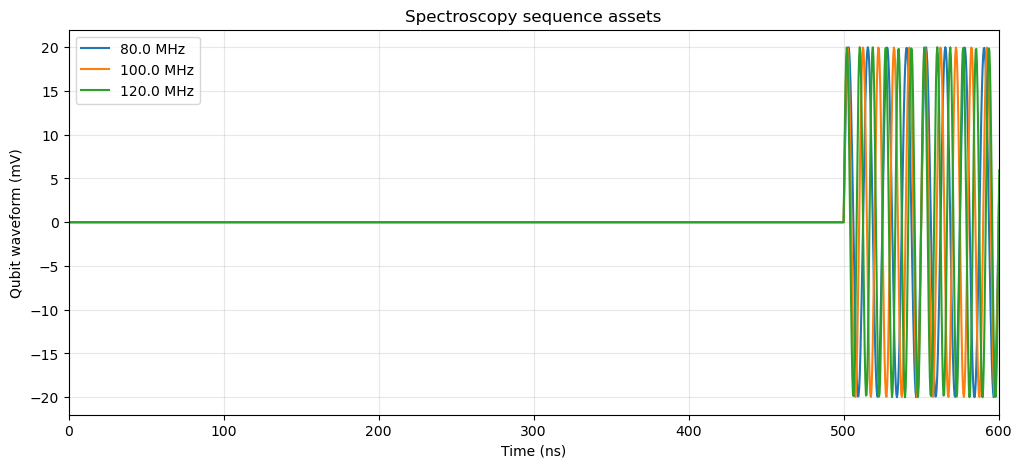

In [4]:
time_ns = (
    np.arange(spectroscopy_compiled.preview(4).shape[1])
    / SAMPLE_RATE_HZ
    / ns
)

plt.figure(figsize=(12, 5))
for index in [0, 10, 20]:
    plt.plot(
        time_ns,
        spectroscopy_compiled.preview(4)[index] * 1e3,
        label=(
            f"{spectroscopy_compiled.axis('frequency')[index] / MHz:.1f} MHz"
        ),
    )
plt.xlim(0, 600)
plt.xlabel("Time (ns)")
plt.ylabel("Qubit waveform (mV)")
plt.title("Spectroscopy sequence assets")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Power Rabi: sequence list changes gain

In [ ]:
power_rabi_cfg = {
    **base_cfg,
    "gain_start": 0.0,
    "gain_stop": 0.08,
    "steps": 9,
    "qubit_len": 100 * ns,
    "qubit_sigma": 15 * ns,
}

power_rabi = PowerRabiProgram(power_rabi_cfg)
power_rabi_compiled = power_rabi.compile(
    sample_rate_hz=SAMPLE_RATE_HZ,
)

gain = power_rabi_compiled.axis("gain")
peak = np.max(np.abs(power_rabi_compiled.preview(4)), axis=1)

plt.figure(figsize=(7, 4))
plt.plot(gain, peak, "o-")
plt.xlabel("Programmed gain (V)")
plt.ylabel("Compiled waveform peak (V)")
plt.title("Power Rabi compile-time gain sweep")
plt.grid(True, alpha=0.3)
plt.show()

## T1: delay_auto sweep

In [ ]:
t1_cfg = {
    **base_cfg,
    "delay_start": 0,
    "delay_stop": 2 * us,
    "steps": 11,
    "pi_len": 100 * ns,
    "pi_sigma": 15 * ns,
    "pi_gain": 0.04,
}

t1 = T1Program(t1_cfg)
t1_compiled = t1.compile(sample_rate_hz=SAMPLE_RATE_HZ)

print("Delay axis (us):", t1_compiled.axis("delay") / us)
print("Fixed step duration (us):", t1_compiled.step_duration_s / us)

In [ ]:
time_ns = np.arange(t1_compiled.preview(3).shape[1]) / SAMPLE_RATE_HZ / ns

plt.figure(figsize=(12, 5))
for index in [0, 5, 10]:
    plt.plot(
        time_ns,
        t1_compiled.preview(3)[index] * 1e3,
        label=f"delay={t1_compiled.axis('delay')[index] / us:.1f} us",
    )
plt.xlabel("Sequence step time (ns)")
plt.ylabel("Readout waveform (mV)")
plt.title("T1 readout moves while every sequence step remains fixed length")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Single-shot ground/excited sequence

In [ ]:
single_shot_cfg = {
    **base_cfg,
    "pi_len": 100 * ns,
    "pi_sigma": 15 * ns,
    "pi_gain": 0.04,
}

single_shot = SingleShotProgram(single_shot_cfg)
single_shot_compiled = single_shot.compile(
    sample_rate_hz=SAMPLE_RATE_HZ,
)

print("State axis:", single_shot_compiled.axis("state"))
print(
    "Ground qubit peak:",
    np.max(np.abs(single_shot_compiled.preview(4)[0])),
)
print(
    "Excited qubit peak:",
    np.max(np.abs(single_shot_compiled.preview(4)[1])),
)

## SGS100A microwave LO

Connect to the SGS100A at `192.168.10.90`, set the microwave carrier to
6 GHz at 0 dBm, route the carrier to the rear `REF/LO OUT` connector, and
enable the main RF output.

Run this cell before the hardware acquisition sections.

In [18]:
from QAWG.instrument import RohdeSchwarzSGS100A

SGS100A_ADDRESS = "192.168.10.90"
LO_FREQUENCY_HZ = 6e9
LO_POWER_DBM = 0.0

sgs = RohdeSchwarzSGS100A(SGS100A_ADDRESS)
sgs.frequency = LO_FREQUENCY_HZ
sgs.power = LO_POWER_DBM
sgs.IQ_state = "on"
sgs.pulsemod_state = "off"
sgs.configure_lo_output(True, mode="LO")
sgs.off()

print("SGS100A:", sgs.idn())
print(f"Frequency: {sgs.frequency / 1e9:.9f} GHz")
print(f"Power: {sgs.power:.3f} dBm")
print("Main RF output:", sgs.status)
print("External IQ modulation:", sgs.IQ_state)
print("Pulse modulation:", sgs.pulsemod_state)
print("Rear REF/LO output:", sgs.ref_lo_output)
print("Instrument error:", sgs.check_error())

Connected to: Rohde&Schwarz,SGS100A,1416.0505k02/112369,4.2.76.0-4.30.046.295
SGS100A: Rohde&Schwarz,SGS100A,1416.0505k02/112369,4.2.76.0-4.30.046.295
Frequency: 6.000000000 GHz
Power: 0.000 dBm
Main RF output: off
External IQ modulation: on
Pulse modulation: off
Rear REF/LO output: LO
Instrument Status: 0,"No error"
Instrument error: 0,"No error"


## Hardware TOF loopback test

Connect the selected AWG analog output to the SGS100A I input and route the
SGS100A RF output through the mixer to the selected ATS9371 input.

The Gaussian-square pulse and Alazar marker are both scheduled at `t=0`.
Therefore the measured pulse arrival time is the total loopback time of flight
through the AWG output path, cable, and ATS acquisition path.

The analog I waveform and marker may share the same AWG channel. The marker
uses marker bits embedded in that channel's waveform data.

Run the following three cells in order.

In [5]:
from QAWG import ExperimentProgram, ns, us


class TOFProgram(ExperimentProgram):
    def _initialize(self, cfg):
        self.declare_gen(
            "loopback",
            ch=cfg["awg_ch"],
            amplitude_vpp=cfg["channel_amplitude_vpp"],
        )
        self.declare_readout(
            "ro",
            adc_channel=cfg["adc_channel"],
            length=cfg["acquire_length"],
            demod_freq=cfg["frequency"],
            waveform_ch=cfg["awg_ch"],
            marker_channel=cfg["marker_ch"],
            marker_padding=cfg["marker_padding"],
            integrate_time=cfg["integrate_time"],
        )
        self.add_pulse(
            "tof_pulse",
            gen="loopback",
            style="gaussian_square",
            length=cfg["pulse_length"],
            edge_sigma=cfg["edge_sigma"],
            frequency=cfg["frequency"],
            gain=cfg["pulse_gain"],
            readout=True,
        )

    def _body(self, cfg):
        # The compiler shifts this tagged readout pulse when pre-padding is needed.
        self.play("tof_pulse", at=0)
        self.trigger(
            "ro",
            trigger_delay=cfg["trigger_delay"],
        )

In [10]:
from QAWG import AWGAlazar, MHz, ns, us

# Physical wiring:
# AWG channel 1 analog output -> SGS100A I input
# SGS100A RF output -> mixer RF input -> ATS9371 CHB input
# SGS100A rear LO output -> mixer LO input
# AWG channel 1 marker 1 -> ATS9371 external trigger
tof_cfg = {
    "awg_ch": 1,
    "marker_ch": 1,
    "adc_channel": "CHB",
    "channel_amplitude_vpp": 0.5,
    "frequency": 50 * MHz,
    "pulse_length": 600 * ns,
    "marker_padding": 500 * ns,
    "edge_sigma": 20 * ns,
    "pulse_gain": 0.02,
    "acquire_length": 1.5 * us,
    # Initial ATS post-trigger delay. Adjust after measuring the residual TOF.
    "trigger_delay": 0 * ns,
    "integrate_time": 1 * us,
}

TOF_N_AVERAGE = 1000
HARDWARE_ACQUIRE_WINDOW = 1.5 * us

experiment = AWGAlazar.connect(
    "TCPIP0::192.168.10.171::inst0::INSTR",
    awg_sample_rate_hz=2.5e9,
    alazar_sample_rate_hz=1e9,
    acquire_window_s=HARDWARE_ACQUIRE_WINDOW,
    trigger_slope="rising",
    trigger_level=140,
)

tof_program = TOFProgram(tof_cfg, final_delay_s=1 * us)
tof_program.REMOVE_DC_OFFSET = True
tof_compiled = tof_program.compile(hardware=experiment)

if tof_cfg["awg_ch"] == tof_cfg["marker_ch"]:
    print(
        "Analog I and trigger marker share AWG "
        f"CH{tof_cfg['awg_ch']} (supported)."
    )

marker_samples = np.flatnonzero(tof_compiled.marker_waveforms[0])
marker_start_ns = marker_samples[0] / experiment.awg_sample_rate_hz / ns
marker_stop_ns = (marker_samples[-1] + 1) / experiment.awg_sample_rate_hz / ns

print("Sequence steps:", tof_compiled.number_of_sequence_steps)
print("AWG step duration (us):", tof_compiled.step_duration_s / us)
print(f"Analog channel: CH{tof_cfg['awg_ch']}")
print(f"Trigger marker: CH{tof_cfg['marker_ch']} Marker 1")
print(f"Compiled marker window: {marker_start_ns:.3f} to {marker_stop_ns:.3f} ns")
print("Initial ATS post-trigger delay:", tof_cfg["trigger_delay"] / ns, "ns")

Analog I and trigger marker share AWG CH1 (supported).
Sequence steps: 1
AWG step duration (us): 3.0
Analog channel: CH1
Trigger marker: CH1 Marker 1
Compiled marker window: 0.000 to 1600.000 ns
Initial ATS post-trigger delay: 0.0 ns


Initial post-trigger delay: 0.000 ns
Measured readout arrival: 611.461 ns
Compiled readout duration: 600.000 ns
Suggested post-trigger delay: 591.461 ns
Suggested integration window: 0.000 to 640.000 ns
DC offset removal: True


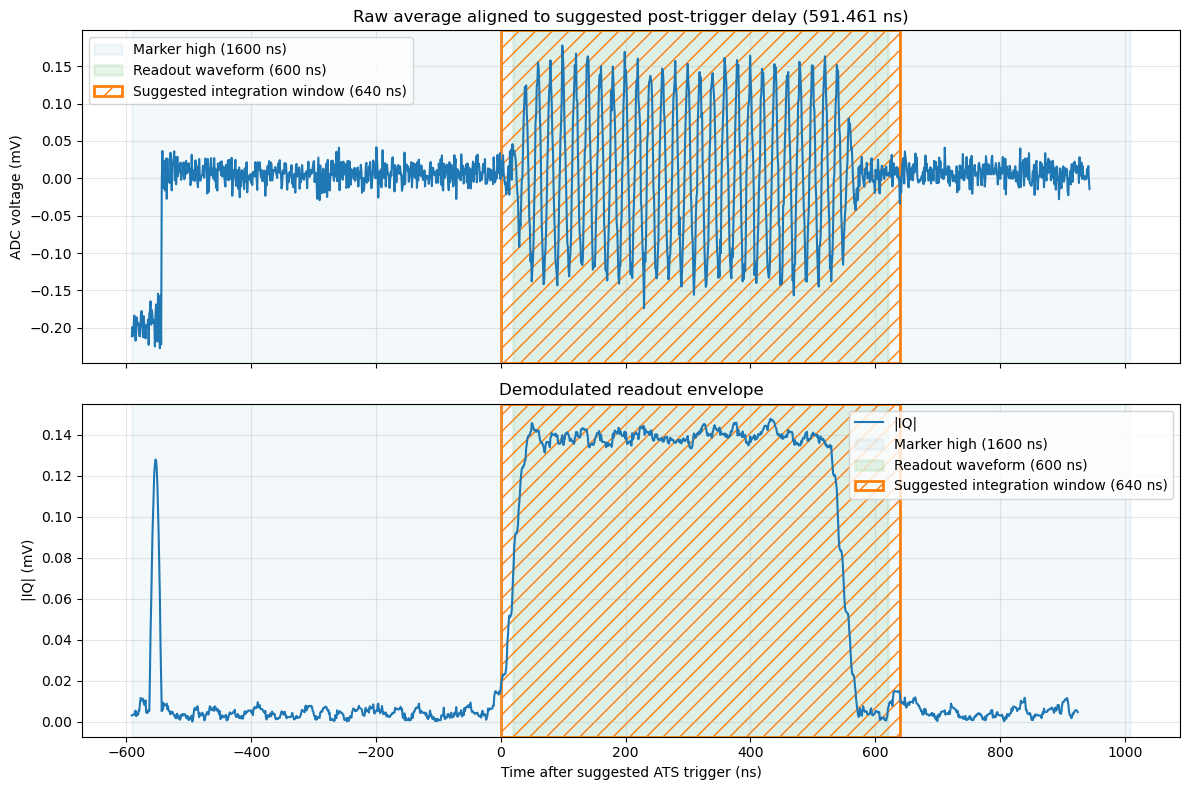

In [11]:
from QAWG import calculate_window

tof_result = tof_compiled.acquire(n_average=TOF_N_AVERAGE)
window = calculate_window(tof_result)

## Hardware Gaussian-square length sweep

This sequence changes the AWG Gaussian-square pulse length from 100 ns to
600 ns. The ATS trigger remains fixed at `t=0`.

`compiled.acquire()` keeps every decimated IQ trace with shape
`(n_average, sequence_step, time)`. Calling `iq_trace_average("ro")` averages
matching records trace by trace, so the changing pulse width remains visible.

In [12]:
from QAWG import ExperimentProgram, LinearSweep, ns


class LengthSweepProgram(ExperimentProgram):
    def _initialize(self, cfg):
        self.declare_gen(
            "loopback",
            ch=cfg["awg_ch"],
            amplitude_vpp=cfg["channel_amplitude_vpp"],
        )
        self.declare_readout(
            "ro",
            adc_channel=cfg["adc_channel"],
            length=cfg["acquire_length"],
            demod_freq=cfg["frequency"],
            waveform_ch=cfg["awg_ch"],
            marker_channel=cfg["marker_ch"],
            marker_padding=cfg["marker_padding"],
            integrate_time=cfg["integrate_time"],
        )
        pulse_length = self.add_sweep(
            "pulse_length",
            LinearSweep(
                cfg["length_start"],
                cfg["length_stop"],
                cfg["length_steps"],
            ),
        )
        self.add_pulse(
            "length_sweep_pulse",
            gen="loopback",
            style="gaussian_square",
            length=pulse_length,
            edge_sigma=cfg["edge_sigma"],
            frequency=cfg["frequency"],
            gain=cfg["pulse_gain"],
            readout=True,
        )

    def _body(self, cfg):
        self.play("length_sweep_pulse", at=0)
        self.trigger(
            "ro",
            trigger_delay=cfg["trigger_delay"],
        )

Pulse lengths (ns): [100. 200. 300. 400. 500. 600.]
All decimated IQ traces: (500, 6, 1517)
Trace-by-trace average: (6, 1517)


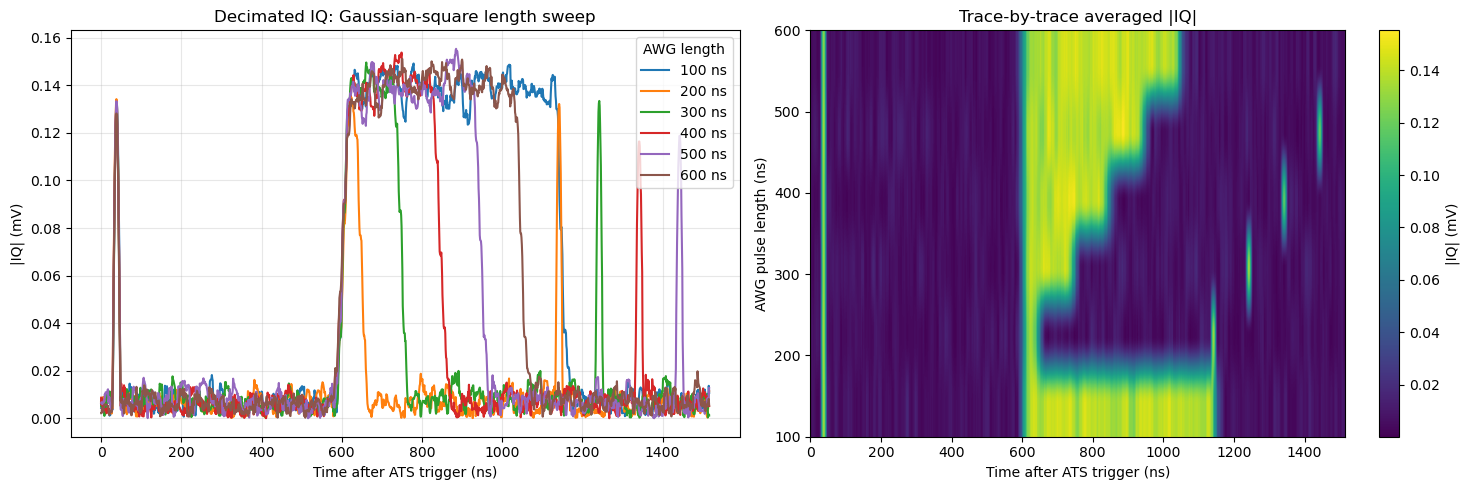

In [13]:
length_sweep_cfg = {
    **tof_cfg,
    "length_start": 100 * ns,
    "length_stop": 600 * ns,
    "length_steps": 6,
    "edge_sigma": 15 * ns,
}
LENGTH_SWEEP_N_AVERAGE = 500

length_program = LengthSweepProgram(
    length_sweep_cfg,
    final_delay_s=1 * us,
)
length_compiled = length_program.compile(hardware=experiment)
length_result = length_compiled.acquire(
    n_average=LENGTH_SWEEP_N_AVERAGE,
    filter_type="boxcar",
)

length_ns = length_result.axis("pulse_length") / ns
length_iq_mv = np.abs(length_result.iq_trace_average("ro")) * 1e3
length_time_ns = length_result.iq_time_s / ns

print("Pulse lengths (ns):", length_ns)
print("All decimated IQ traces:", length_result.iq_traces.shape)
print("Trace-by-trace average:", length_iq_mv.shape)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for index, pulse_length_ns in enumerate(length_ns):
    axes[0].plot(
        length_time_ns,
        length_iq_mv[index],
        label=f"{pulse_length_ns:.0f} ns",
    )
axes[0].set_xlabel("Time after ATS trigger (ns)")
axes[0].set_ylabel("|IQ| (mV)")
axes[0].set_title("Decimated IQ: Gaussian-square length sweep")
axes[0].grid(True, alpha=0.3)
axes[0].legend(title="AWG length")

image = axes[1].imshow(
    length_iq_mv,
    aspect="auto",
    origin="lower",
    extent=[
        length_time_ns[0],
        length_time_ns[-1],
        length_ns[0],
        length_ns[-1],
    ],
)
axes[1].set_xlabel("Time after ATS trigger (ns)")
axes[1].set_ylabel("AWG pulse length (ns)")
axes[1].set_title("Trace-by-trace averaged |IQ|")
fig.colorbar(image, ax=axes[1], label="|IQ| (mV)")

plt.tight_layout()
plt.show()

## Hardware `delay_auto` sweep

Every sequence step uses the same 100 ns Gaussian pulse. Only the relative
delay before the pulse changes:

```text
delay_auto(0 ns)   / Gaussian
delay_auto(40 ns)  / Gaussian
...
delay_auto(200 ns) / Gaussian
```

The ATS trigger stays at `t=0`, so the decimated traces show the waveform
moving later inside the same acquisition window.

In [16]:
class DelayAutoSweepProgram(ExperimentProgram):
    def _initialize(self, cfg):
        self.declare_gen(
            "loopback",
            ch=cfg["awg_ch"],
            amplitude_vpp=cfg["channel_amplitude_vpp"],
        )
        self.declare_readout(
            "ro",
            adc_channel=cfg["adc_channel"],
            length=cfg["acquire_length"],
            demod_freq=cfg["frequency"],
            marker_channel=cfg["marker_ch"],
            marker_length=cfg["marker_length"],
            integrate_time=cfg["integrate_time"],
        )
        self.delay = self.add_sweep(
            "delay",
            LinearSweep(
                cfg["delay_start"],
                cfg["delay_stop"],
                cfg["delay_steps"],
            ),
        )
        self.add_pulse(
            "delayed_gaussian",
            gen="loopback",
            style="gaussian",
            length=cfg["gaussian_length"],
            sigma=cfg["gaussian_sigma"],
            frequency=cfg["frequency"],
            gain=cfg["pulse_gain"],
            readout=True
        )

    def _body(self, cfg):
        self.trigger(
            "ro",
            trigger_delay=cfg["trigger_delay"],
        )
        self.delay_auto(self.delay)
        self.play("delayed_gaussian")

In [17]:
delay_sweep_cfg = {
    **tof_cfg,
    "marker_length": 40 * ns,
    # Keep acquisition fixed at the marker edge so the pulse delay remains visible.
    "trigger_delay": 0 * ns,
    "delay_start": 0 * ns,
    "delay_stop": 200 * ns,
    "delay_steps": 6,
    "gaussian_length": 100 * ns,
    "gaussian_sigma": 15 * ns,
}
DELAY_SWEEP_N_AVERAGE = 500

delay_program = DelayAutoSweepProgram(
    delay_sweep_cfg,
    final_delay_s=1 * us,
)
delay_compiled = delay_program.compile(hardware=experiment)
delay_result = delay_compiled.acquire(
    n_average=DELAY_SWEEP_N_AVERAGE,
    filter_type="boxcar",
)

delay_ns = delay_result.axis("delay") / ns
delay_iq_mv = np.abs(delay_result.iq_trace_average("ro")) * 1e3
delay_time_ns = delay_result.iq_time_s / ns

print("delay_auto values (ns):", delay_ns)
print("All decimated IQ traces:", delay_result.iq_traces.shape)
print("Trace-by-trace average:", delay_iq_mv.shape)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for index, delay_value_ns in enumerate(delay_ns):
    axes[0].plot(
        delay_time_ns,
        delay_iq_mv[index],
        label=f"{delay_value_ns:.0f} ns",
    )
axes[0].set_xlabel("Time after ATS trigger (ns)")
axes[0].set_ylabel("|IQ| (mV)")
axes[0].set_title("Decimated IQ: delay_auto sweep")
axes[0].grid(True, alpha=0.3)
axes[0].legend(title="delay_auto")

image = axes[1].imshow(
    delay_iq_mv,
    aspect="auto",
    origin="lower",
    extent=[
        delay_time_ns[0],
        delay_time_ns[-1],
        delay_ns[0],
        delay_ns[-1],
    ],
)
axes[1].set_xlabel("Time after ATS trigger (ns)")
axes[1].set_ylabel("delay_auto value (ns)")
axes[1].set_title("Identical Gaussian shifted in time")
fig.colorbar(image, ax=axes[1], label="|IQ| (mV)")

plt.tight_layout()
plt.show()

ValueError: Tagged readout pulses require readout waveform_ch

## Hardware single shot: 0 and 180 degree readout

This sequence contains two readout steps with exactly the same waveform
length, frequency, and amplitude. Only the carrier phase changes:

```text
step 0: readout phase =   0 degrees
step 1: readout phase = 180 degrees
```

The waveform length equals the declared readout length. Every acquisition is
kept as an individual shot.

In [ ]:
from QAWG import ExperimentProgram, ValuesSweep


class PhaseSingleShotProgram(ExperimentProgram):
    def _initialize(self, cfg):
        self.declare_gen(
            "readout",
            ch=cfg["readout_ch"],
            amplitude_vpp=cfg["channel_amplitude_vpp"],
        )
        self.declare_readout(
            "ro",
            adc_channel=cfg["adc_channel"],
            length=cfg["readout_length"],
            demod_freq=cfg["frequency"],
            waveform_ch=cfg["readout_ch"],
            marker_channel=cfg["marker_ch"],
            marker_padding=cfg["marker_padding"],
            integrate_time=cfg["readout_length"],
        )
        phase = self.add_sweep(
            "phase",
            ValuesSweep((0.0, np.pi)),
        )
        self.add_pulse(
            "readout_pulse",
            gen="readout",
            style="const",
            length=cfg["readout_length"],
            frequency=cfg["frequency"],
            phase=phase,
            gain=cfg["readout_gain"],
            readout=True,
        )

    def _body(self, cfg):
        self.play("readout_pulse", at=0)
        self.trigger(
            "ro",
            trigger_delay=cfg["trigger_delay"],
        )

In [ ]:
phase_single_shot_cfg = {
    "readout_ch": tof_cfg["awg_ch"],
    "marker_ch": tof_cfg["marker_ch"],
    "adc_channel": tof_cfg["adc_channel"],
    "channel_amplitude_vpp": tof_cfg["channel_amplitude_vpp"],
    "frequency": tof_cfg["frequency"],
    "readout_length": 1 * us,
    "readout_gain": tof_cfg["pulse_gain"],
    "marker_padding": tof_cfg["marker_padding"],
    "trigger_delay": tof_cfg["trigger_delay"],
}
SINGLE_SHOT_N_AVERAGE = 1000

phase_single_shot = PhaseSingleShotProgram(
    phase_single_shot_cfg,
    final_delay_s=1 * us,
)
phase_single_shot_compiled = phase_single_shot.compile(
    hardware=experiment,
)
phase_single_shot_result = phase_single_shot_compiled.acquire(
    n_average=SINGLE_SHOT_N_AVERAGE,
    filter_type="boxcar",
)

phase_degrees = np.rad2deg(
    phase_single_shot_result.axis("phase")
)
print("Phase steps (degrees):", phase_degrees)
print(
    "Raw records (shot, phase, time):",
    phase_single_shot_result.raw.shape,
)

### Trajectory from raw downconverted data

The calculation below starts from the unfiltered ADC voltage records. It
performs complex digital downconversion and then computes the cumulative IQ
average independently for every shot:

```python
trajectory[..., n] = mean(raw_downconverted[..., :n + 1])
```

No averaging between shots is performed before constructing the trajectories.

In [ ]:
raw_records = phase_single_shot_result.raw
raw_time_s = phase_single_shot_result.raw_time_s
frequency_hz = phase_single_shot_cfg["frequency"]
readout_samples = int(round(
    phase_single_shot_cfg["readout_length"]
    * experiment.alazar_sample_rate_hz
))

# ATS record length is aligned to the hardware block size. Do not integrate
# the zero-padded tail after the physical readout waveform has ended.
raw_records = raw_records[:, :, :readout_samples]
raw_time_s = raw_time_s[:readout_samples]

# Same convention as QAWG.alazar.digital_downconvert(), without filtering.
digital_reference = np.exp(
    -1j * 2 * np.pi * frequency_hz * raw_time_s
)
raw_downconverted = 2.0 * raw_records * digital_reference[None, None, :]

sample_count = np.arange(
    1,
    raw_downconverted.shape[2] + 1,
    dtype=float,
)
trajectory = np.cumsum(raw_downconverted, axis=2)
trajectory /= sample_count[None, None, :]

integration_time_ns = sample_count / experiment.alazar_sample_rate_hz / ns
final_iq_mv = trajectory[:, :, -1] * 1e3

print(
    "Raw downconverted IQ (shot, phase, time):",
    raw_downconverted.shape,
)
print("IQ trajectory:", trajectory.shape)
print(
    "Trajectory integration stop:",
    f"{integration_time_ns[-1]:.0f} ns "
    "(physical readout length)",
)

colors = ["tab:blue", "tab:orange"]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot a readable subset of individual trajectories plus the shot mean.
shots_to_plot = min(50, SINGLE_SHOT_N_AVERAGE)
trajectory_mv = trajectory * 1e3
for phase_index, phase_degree in enumerate(phase_degrees):
    for shot_index in range(shots_to_plot):
        axes[0].plot(
            trajectory_mv[shot_index, phase_index].real,
            trajectory_mv[shot_index, phase_index].imag,
            color=colors[phase_index],
            alpha=0.08,
            linewidth=0.7,
        )
    mean_trajectory = np.mean(
        trajectory_mv[:, phase_index],
        axis=0,
    )
    axes[0].plot(
        mean_trajectory.real,
        mean_trajectory.imag,
        color=colors[phase_index],
        linewidth=2.5,
        label=f"{phase_degree:.0f} degree mean",
    )

    axes[1].scatter(
        final_iq_mv[:, phase_index].real,
        final_iq_mv[:, phase_index].imag,
        s=10,
        alpha=0.35,
        color=colors[phase_index],
        label=f"{phase_degree:.0f} degrees",
    )

axes[0].set_xlabel("Cumulative I (mV)")
axes[0].set_ylabel("Cumulative Q (mV)")
axes[0].set_title("Single-shot IQ trajectories")
axes[0].axis("equal")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_xlabel("Final I (mV)")
axes[1].set_ylabel("Final Q (mV)")
axes[1].set_title(
    f"Final IQ after {integration_time_ns[-1]:.0f} ns integration"
)
axes[1].axis("equal")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Close hardware sessions

In [ ]:
# Turn off microwave power before closing instrument sessions.
if "sgs" in globals():
    sgs.off()
    sgs.configure_lo_output(False)
    sgs.close()
    print("SGS100A RF and rear LO outputs disabled")

if "experiment" in globals():
    experiment.close()
    print("AWG VISA session closed")